In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
#load data 
df = pd.read_csv('training_data.csv')
numeric_df = df.select_dtypes(include=[np.number])


C:\Users\44757\AppData\Local\Temp\ipykernel_73068\154597810.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=position_counts.index, y=position_counts.values, palette='viridis')


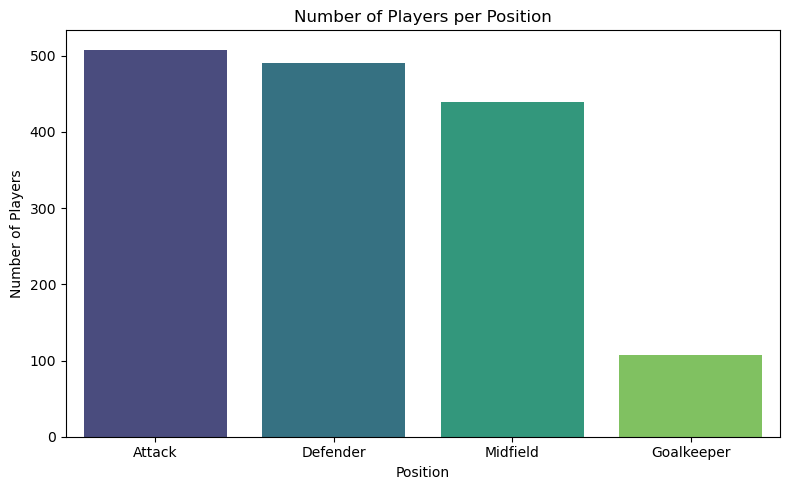

In [ ]:
#plot the number of players per position in the dataset 
plt.figure(figsize=(8, 5))
position_counts = df['position'].value_counts()
sns.barplot(x=position_counts.index, y=position_counts.values, palette='viridis')
plt.title('Number of Players per Position')
plt.xlabel('Position')
plt.ylabel('Number of Players')
plt.tight_layout()
plt.show()

In [ ]:
#split training data into outfield players and goalkeepers

# Filter for Goalkeepers
raw_gk_train_df = df[df['position'] == 'Goalkeeper']

# Filter for Outfield Players 
raw_outfield_train_df = df[df['position'] != 'Goalkeeper']

# Save the split datasets to new files
raw_gk_train_df.to_csv('raw_training_data_goalkeepers.csv', index=False)
raw_outfield_train_df.to_csv('raw_training_data_outfield.csv', index=False)

print(f" Data split into outfield players and goalkeepers")



#load testing data
test_df = pd.read_csv('testing_data.csv')

# filter for outfield players
raw_gk_test_df = test_df[test_df['position'] == 'Goalkeeper']
raw_outfield_test_df = test_df[test_df['position'] != 'Goalkeeper']

# Save the  splits
raw_gk_test_df.to_csv('raw_testing_data_goalkeepers.csv', index=False)
raw_outfield_test_df.to_csv('raw_testing_data_outfield.csv', index=False)

print(f"Testing data split into Outfield Players and goalkeeprs")

In [14]:
#load data outfield players
outfield_df = pd.read_csv('raw_training_data_outfield.csv')
outfield_numeric_df = outfield_df.select_dtypes(include=[np.number])
 
 #load goalkeeper data
gk_df = pd.read_csv('raw_training_data_goalkeepers.csv')
goalkeeper_numeric_df = gk_df.select_dtypes(include=[np.number])


target = 'transfer_fee'



C:\Users\44757\AppData\Local\Temp\ipykernel_73068\2667017957.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='viridis')


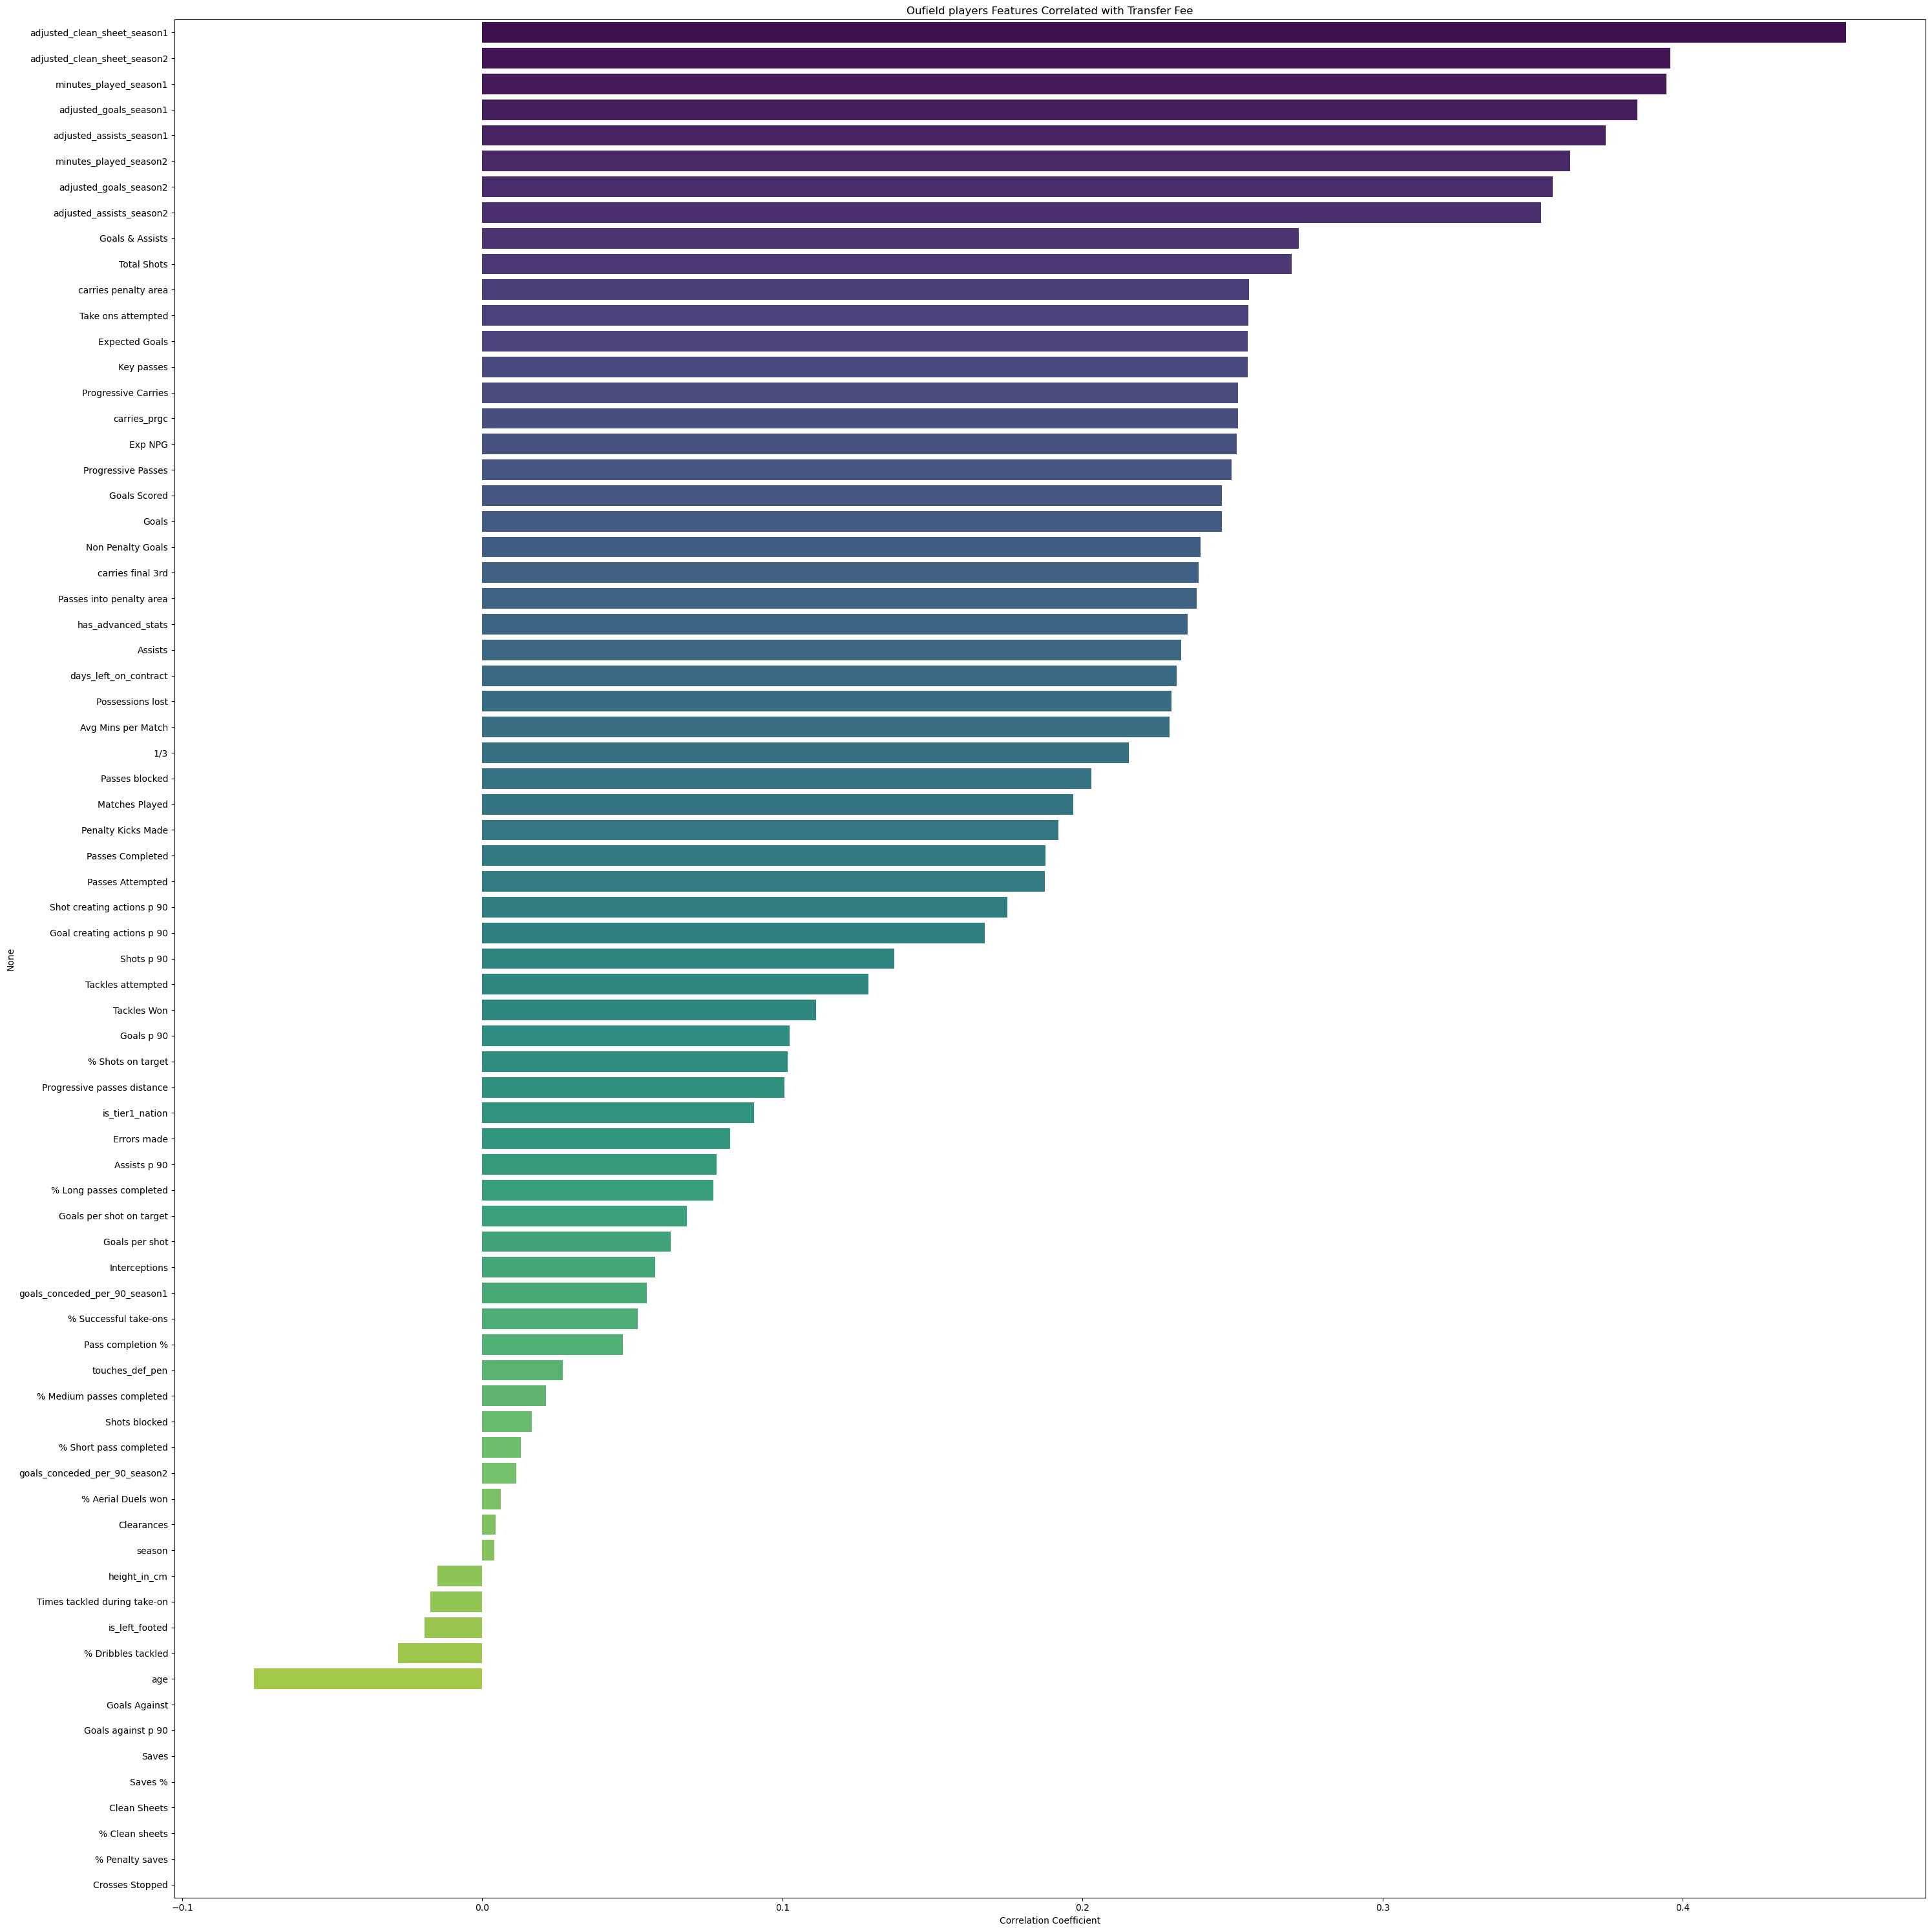

In [15]:
corr_with_target = outfield_numeric_df.corr()[target].drop(target).sort_values(ascending=False)

plt.figure(figsize=(30, 30)) 
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='viridis')
plt.title('Oufield players Features Correlated with Transfer Fee')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

C:\Users\44757\AppData\Local\Temp\ipykernel_73068\1724130002.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='viridis')


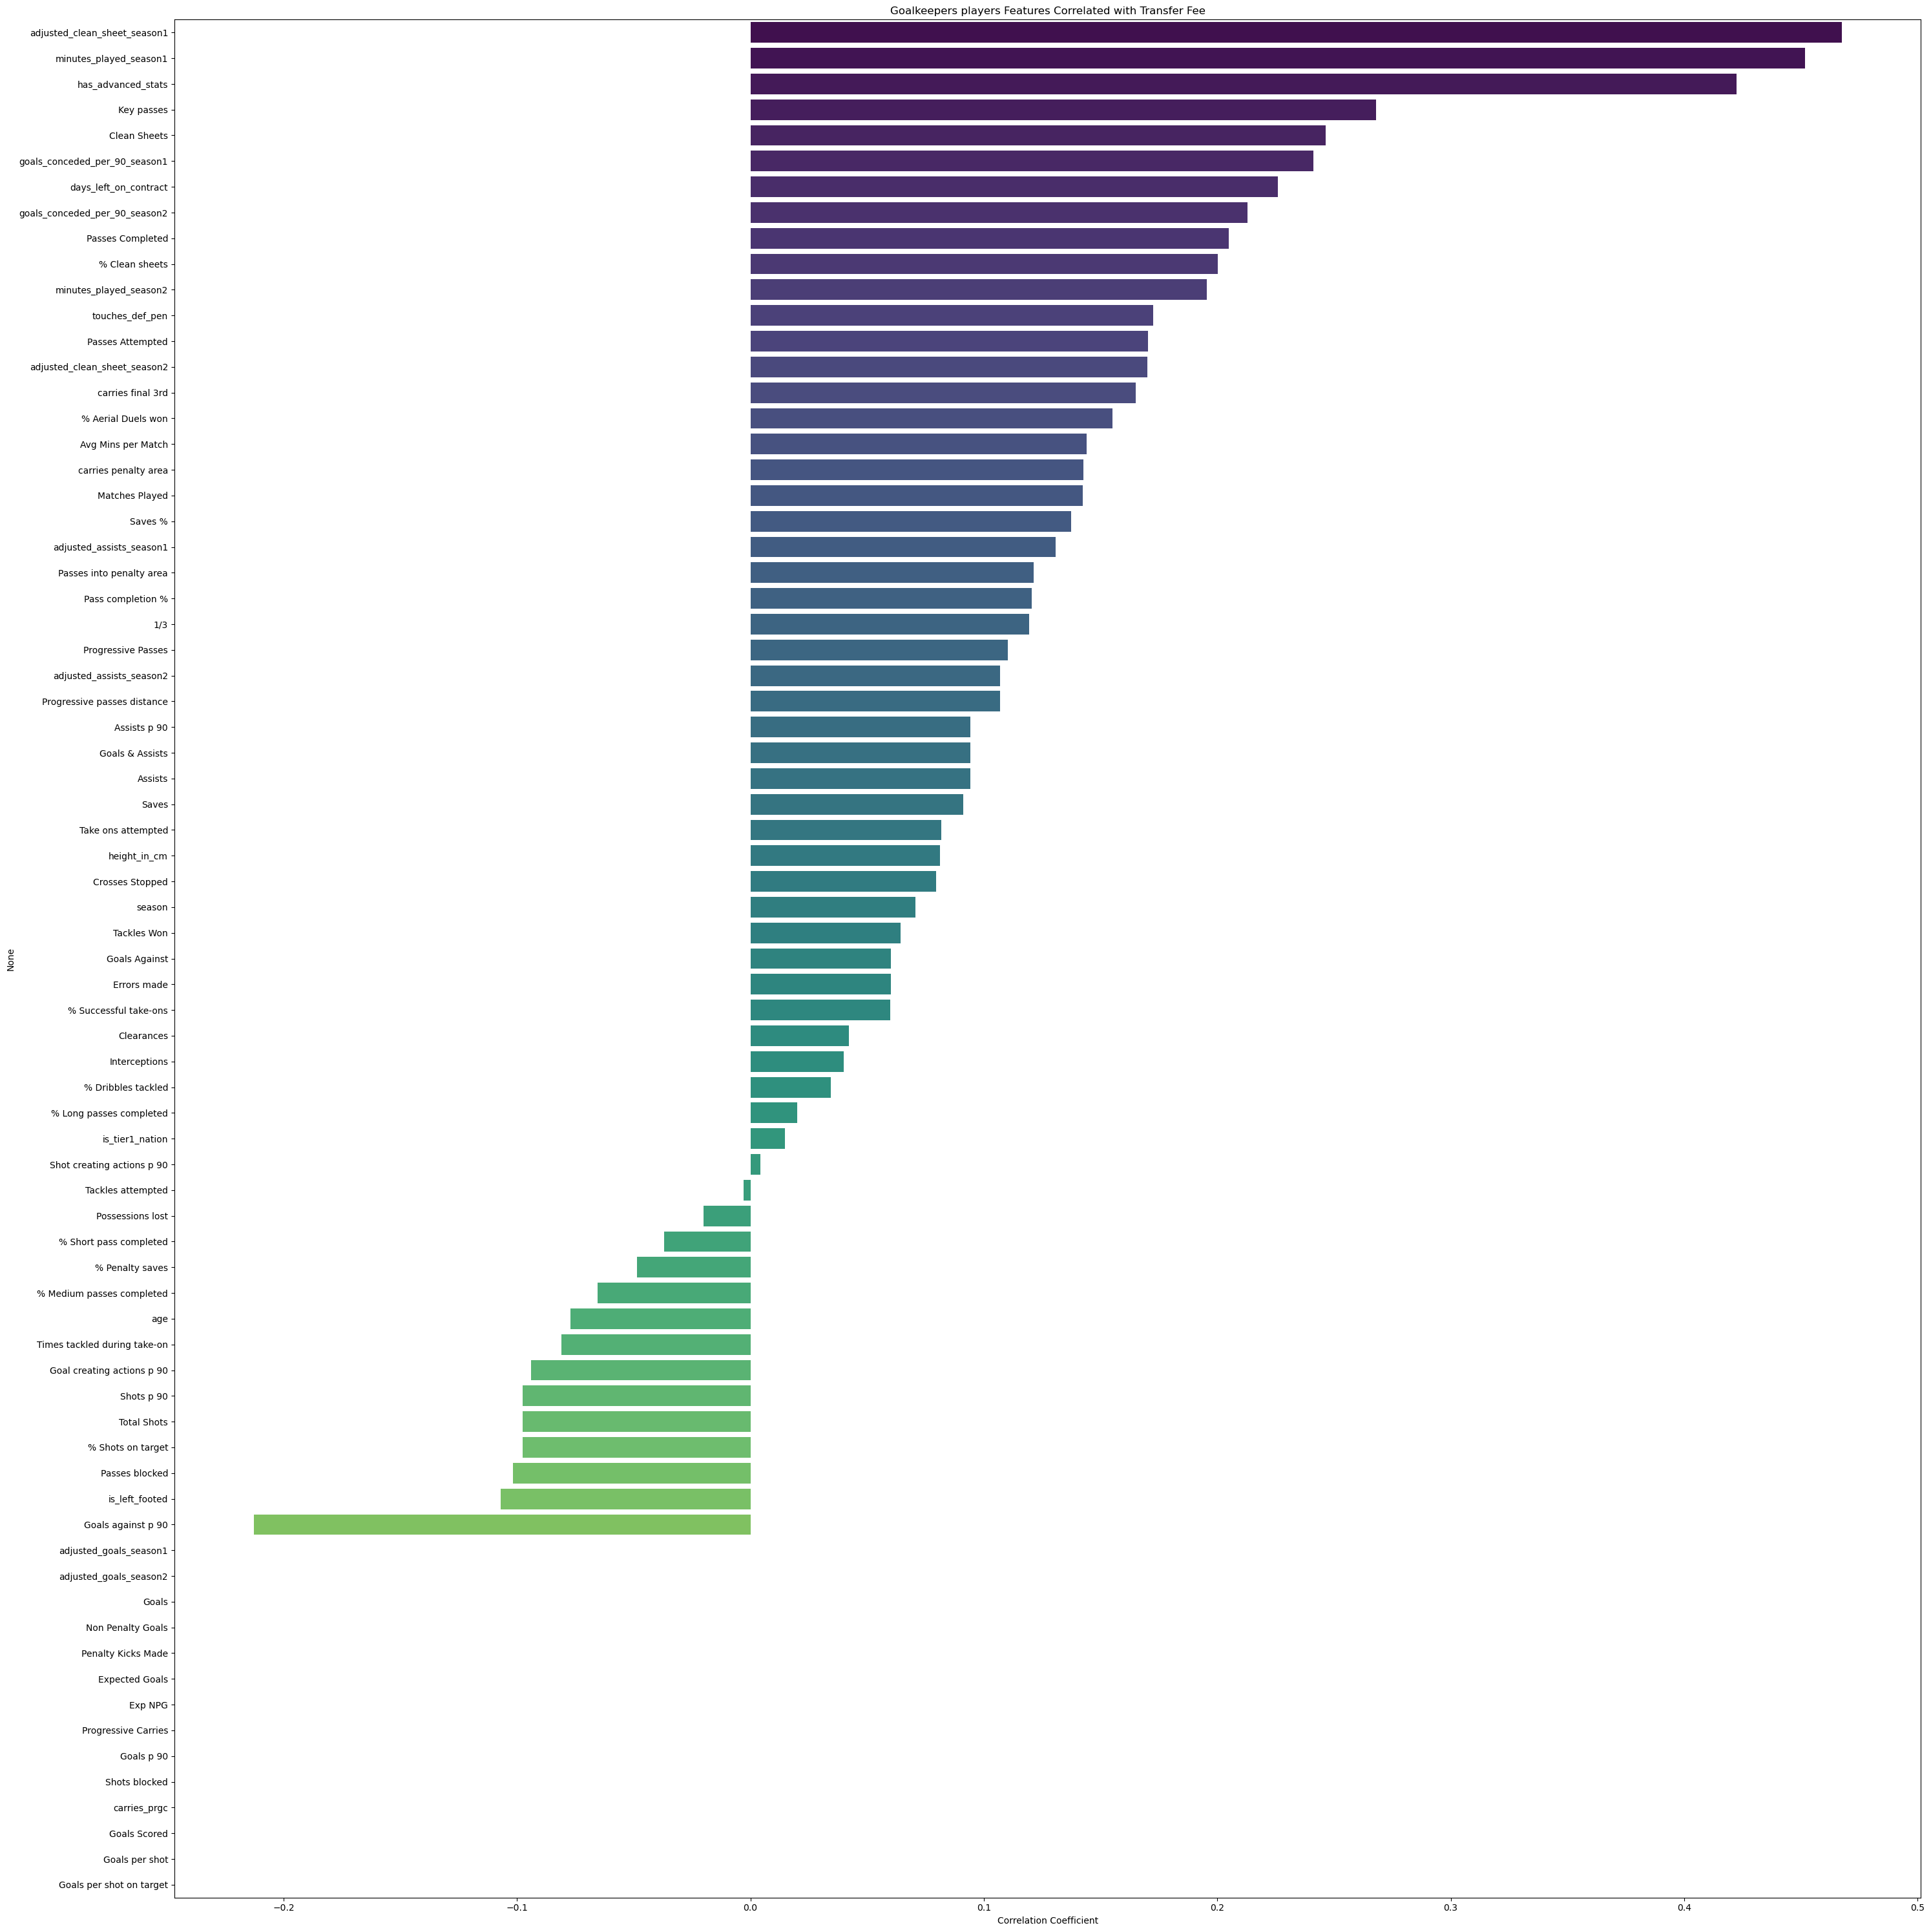

In [16]:
corr_with_target = goalkeeper_numeric_df.corr()[target].drop(target).sort_values(ascending=False)

plt.figure(figsize=(30, 30)) 
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='viridis')
plt.title('Goalkeepers players Features Correlated with Transfer Fee')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

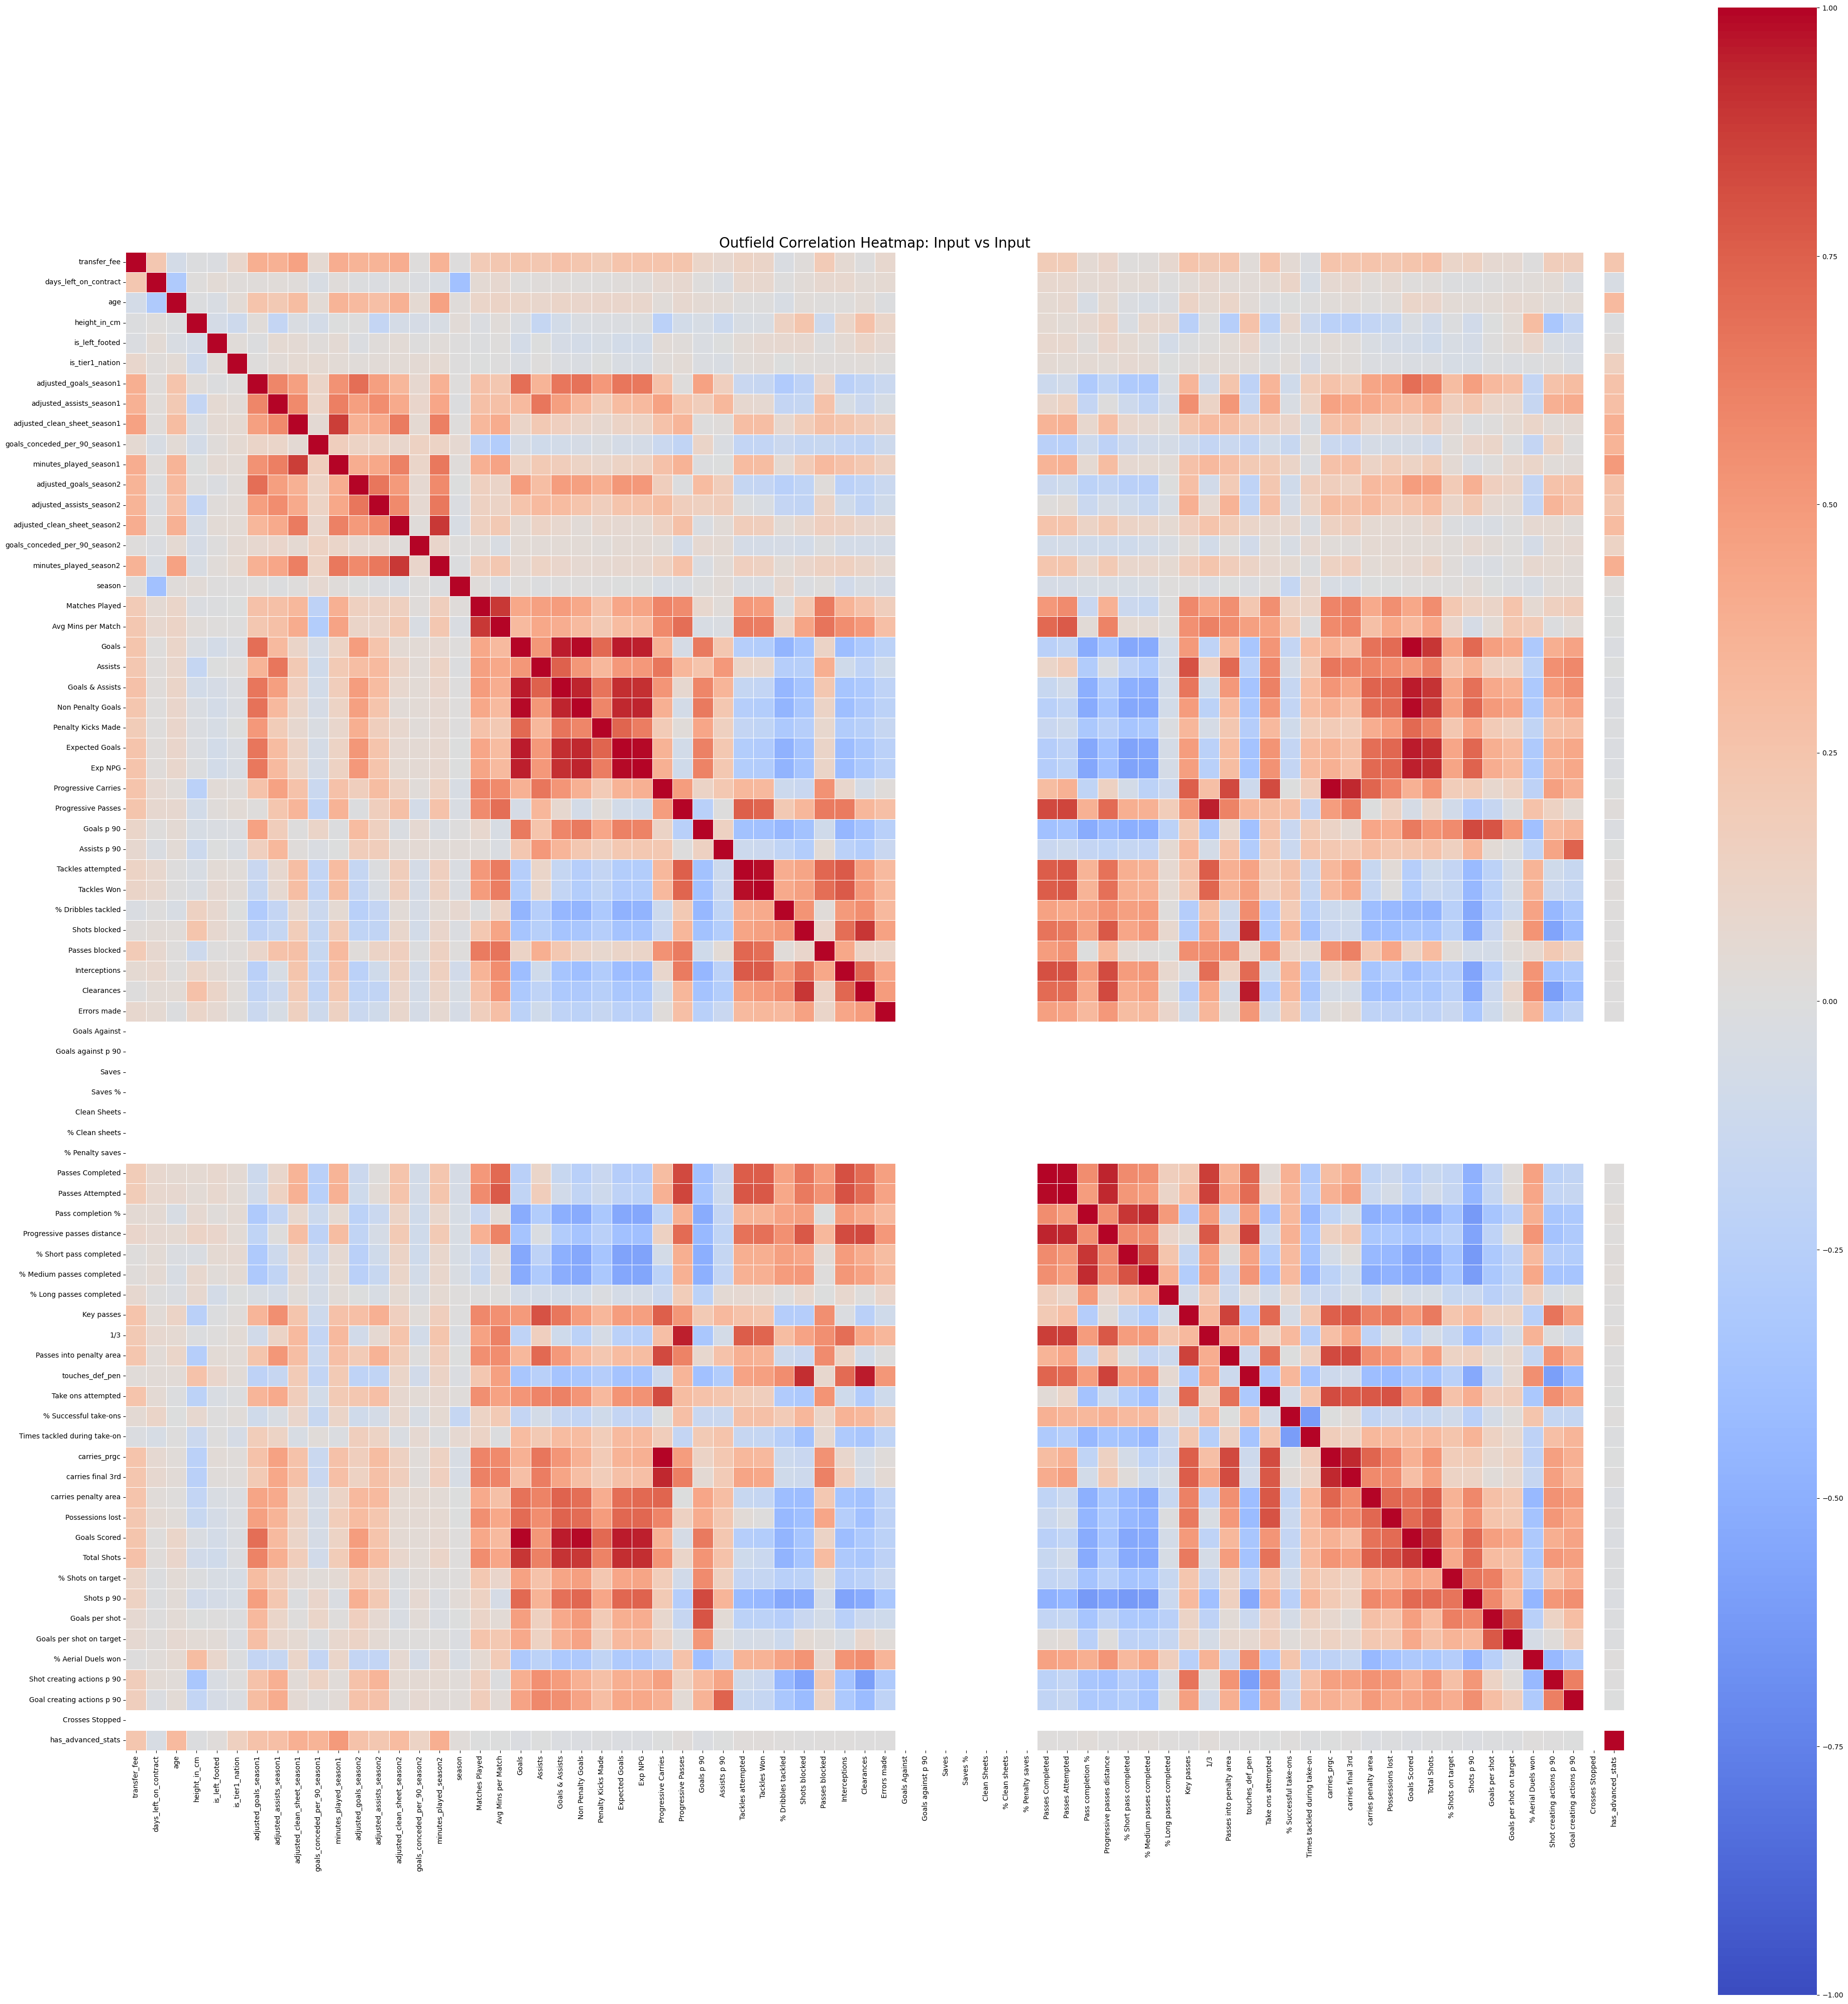

In [20]:
corr_matrix = outfield_numeric_df.corr()

plt.figure(figsize=(40,40)) 
sns.heatmap(corr_matrix, 
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            square=True, 
            linewidths=0.5)

plt.title('Outfield Correlation Heatmap: Input vs Input', fontsize=20)
plt.tight_layout()
plt.show()

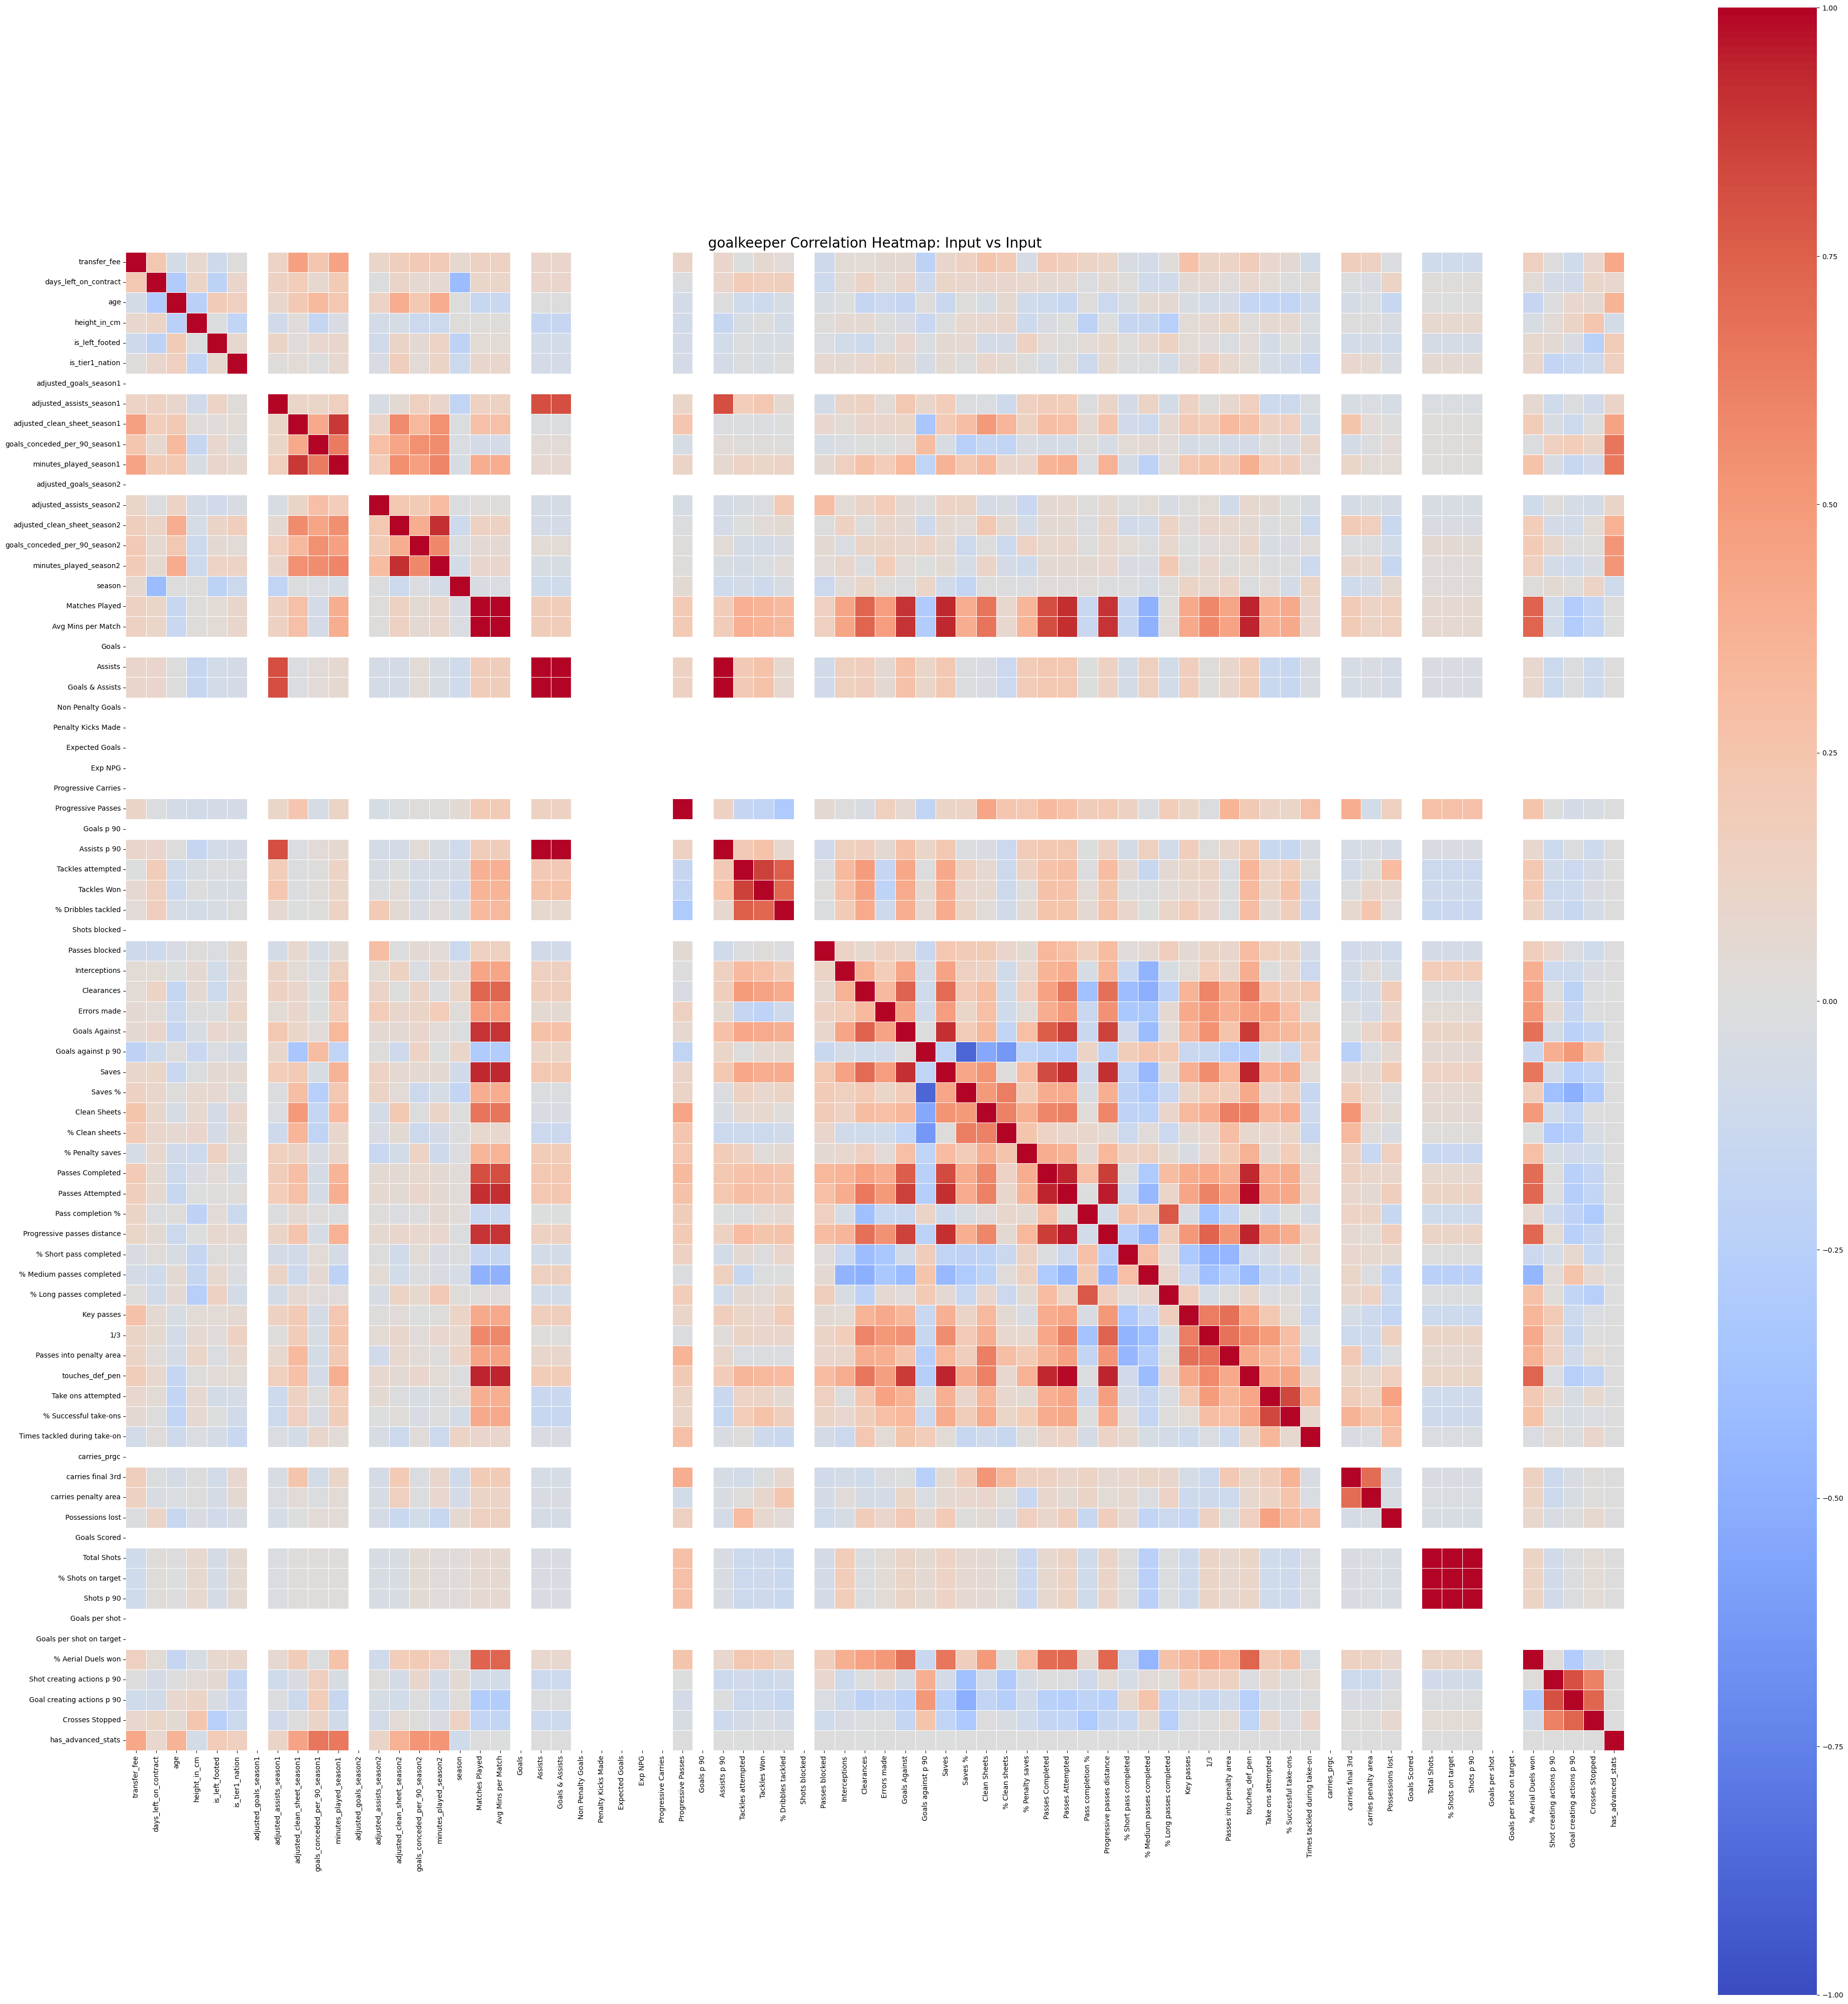

In [21]:
corr_matrix = goalkeeper_numeric_df.corr()

plt.figure(figsize=(40,40)) 
sns.heatmap(corr_matrix, 
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            square=True, 
            linewidths=0.5)

plt.title('goalkeeper Correlation Heatmap: Input vs Input', fontsize=20)
plt.tight_layout()
plt.show()